# Data parsing
Parse data from its binary form (idx) and then flip and normalise it

In [1]:
import numpy as np
import struct
import os

def validate_path(path: str):
    if path is None:
        return False
    return os.path.exists(path)

def get_idx_type(path):
    magic_number = int.from_bytes(open(path, 'rb').read(4), byteorder='big')
    magic_number_mapping = {
        0x00000801: 1,
        0x00000803: 3
    }
    return magic_number_mapping.get(magic_number, "Unknown")

def normalize_images(data):
    return data / 255.0

def reshape_data(data):
    print('Previous shape : {}'.format(data.shape))
    if len(data.shape) != 3:
        return Exception("Data is not in the correct shape")
    size = data.shape[0]
    height = data.shape[1]
    width = data.shape[2]
    data = data.reshape(size, height * width)
    print('New shape : {}'.format(data.shape))
    return data
    

def get_unique_labels(labels : np.ndarray = None, path : str = None):
    if validate_path(path) == False:
        print("Path does not exist.")
        return None
    if path is not None:
        if get_idx_type(path) != 1:
            print("Wrong idx type detected. Please use idx1 files.")
            return None
        with open(path, 'rb') as f:
            header = f.read(8)
            labels = set(f.read())
    elif labels is not None:
        labels = set(labels)
        return len(labels)
    else:
        print("No labels provided.")
        return None        

def parse_binary_file(path, debug=False):
    magic_number = get_idx_type(path)
    with open(path, 'rb') as f:
        _, size = struct.unpack('>II', f.read(8))
        if magic_number == 1:
            data = np.fromfile(f, dtype=np.uint8).newbyteorder('>')
            data = data.reshape(size)
            if debug:
                print(f"Magic number: {magic_number}")
                print(f"Size: {size}")
            return data
        elif magic_number == 3:
            nrows, ncols = struct.unpack(">II", f.read(8))
            data = np.fromfile(f, dtype=np.uint8).newbyteorder('>')
            # Reshapes to Images x Height x Width
            data = data.reshape(size, nrows, ncols)
            # Flip images so they are right side up
            data = np.transpose(data, (0, 2, 1))
            # Normalize images
            data = normalize_images(data)
            # Reshape to Images x (Height * Width)
            # data = reshape_data(data)
            if debug:
                print(f"Magic number: {magic_number}")
                print(f"Size: {size}")
                print(f"Height: {nrows} px")
                print(f"Width: {ncols} px")
            return data
        else:
            print(f"Unknown file type: {magic_number}")
            return None

def filter_images(images : np.array, labels : np.array, class_map: str, filter_labels : str) :
    filter_labels = set(filter_labels)
    if len(filter_labels) == 0:
        return images, labels
    filtered_data = [(img, label) for img, label in zip(images, labels) if str(class_map[label]) in filter_labels]
    filtered_images, filtered_labels = zip(*filtered_data)
    filtered_images = np.array(filtered_images)
    filtered_labels = np.array(filtered_labels)
    return filtered_images, filtered_labels
    

train_images = parse_binary_file("../input/emnist_source_files/emnist-bymerge-train-images-idx3-ubyte")
train_labels = parse_binary_file("../input/emnist_source_files/emnist-bymerge-train-labels-idx1-ubyte")
train_unique_labels = get_unique_labels(path="../input/emnist_source_files/emnist-bymerge-train-labels-idx1-ubyte")
test_images = parse_binary_file("../input/emnist_source_files/emnist-bymerge-test-images-idx3-ubyte")
test_labels = parse_binary_file("../input/emnist_source_files/emnist-bymerge-test-labels-idx1-ubyte")
test_unique_labels = get_unique_labels(path="../input/emnist_source_files/emnist-bymerge-test-labels-idx1-ubyte")
only_o_and_q_images, only_o_and_q_labels = filter_images(train_images, train_labels, "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt","QO")
print("Images : {} | Labels : {}".format(only_o_and_q_images.shape, only_o_and_q_labels.shape))


Images : (30267, 28, 28) | Labels : (30267,)


# Setting the GPU parameters

In [3]:
def setTensorflowGPUParams():
    from os import environ
    environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
    environ['KERAS_BACKEND'] = 'tensorflow'
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    #tf.debugging.set_log_device_placement(True)
    tf.test.is_gpu_available()
    devices = tf.config.experimental.list_physical_devices('GPU')
    GPU = devices[0]
    try:
        tf.config.experimental.set_memory_growth(GPU, True)
    except:
        pass
setTensorflowGPUParams()

2024-02-24 12:54:25.628867: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 12:54:25.629083: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 12:54:25.629228: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

(116323, 28, 28)


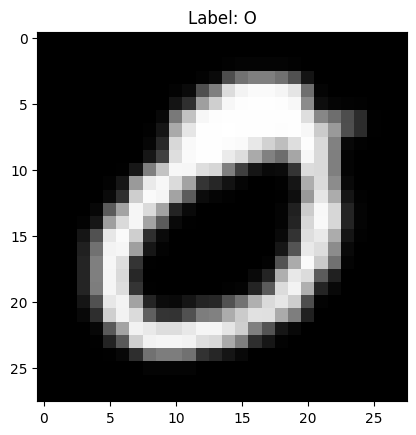

In [4]:
import matplotlib.pyplot as plt
print(test_images.shape)
class_mapping = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt"
number_of_classes = len(class_mapping)
index_number = 0
plt.imshow(only_o_and_q_images[index_number], cmap='gray')
plt.title(f"Label: {class_mapping[only_o_and_q_labels[index_number]]}")
plt.show()

Rows: 2 | Cols: 10


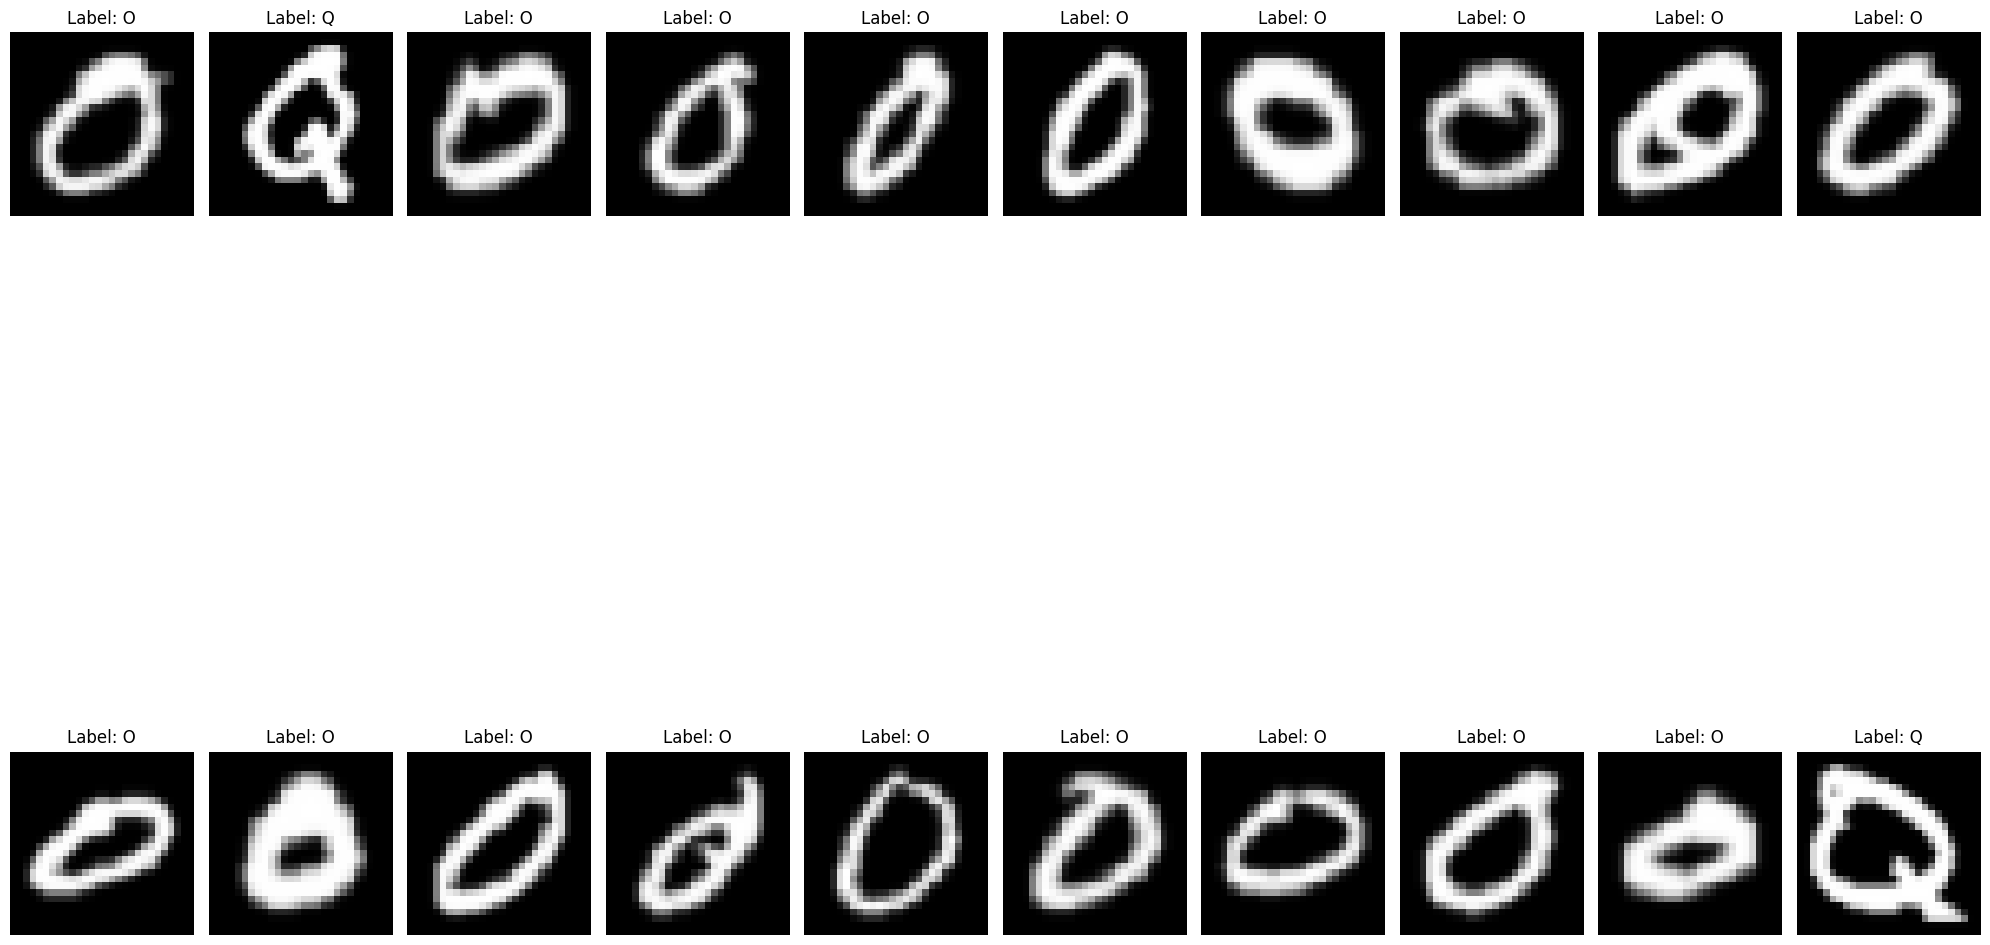

In [5]:
import matplotlib.pyplot as plt
def plot_images(images, labels, class_mapping, number_of_images=10):
    cols = min(number_of_images, 10)
    rows = (number_of_images + cols - 1) // cols
    print(f"Rows: {rows} | Cols: {cols}")
    
    fig = plt.figure(figsize=(20, 20))
    
    for i in range(number_of_images):
        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(images[i], cmap='gray')
        ax.set_title(f"Label: {class_mapping[labels[i]]}")
        ax.axis('off')  # Hide axes for cleaner look

    plt.tight_layout()  # Adjusts subplot params so that subplots are nicely fit in the figure
    plt.show()

plot_images(only_o_and_q_images, only_o_and_q_labels, class_mapping, 20)